[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_08/notebook_8_3_bert_classification.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# BERT for Clinical Text Classification

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand BERT architecture** and contextualized embeddings
2. **Compare traditional vs. BERT-based** approaches for clinical text classification
3. **Fine-tune ClinicalBERT** for specialty classification tasks
4. **Implement BERT using HuggingFace** Transformers library
5. **Evaluate and interpret** BERT model predictions

## Clinical Context

**Clinical Scenario**: Automated routing of clinical case summaries to appropriate specialty departments:
- **Cardiology**: Heart failure, arrhythmias, MI
- **Pulmonology**: COPD, pneumonia, asthma
- **Endocrinology**: Diabetes, thyroid disorders
- **Neurology**: Stroke, seizures, dementia

**Why This Matters**:
- **Triage optimization**: Route cases to correct specialists faster
- **Consultation requests**: Automatically suggest relevant specialists
- **Quality metrics**: Identify specialty-specific care gaps
- **Research cohorts**: Find relevant cases for clinical trials

**Challenge**: Medical text is complex:
- Context-dependent: "discharge" (verb vs. noun)
- Overlapping symptoms: "chest pain" → cardiology, pulmonology, or GI?
- Implicit reasoning: "LVEF 30%" → heart failure → cardiology

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Generate Clinical Case Summaries

We'll create synthetic clinical case summaries across 4 specialties.

In [2]:
# Synthetic clinical case summaries by specialty
cardiology_cases = [
    "Patient presents with acute chest pain radiating to left arm. ECG shows ST elevation. Troponin elevated. Diagnosed with acute myocardial infarction.",
    "65-year-old with worsening dyspnea on exertion. Echocardiography reveals LVEF 30%. BNP elevated at 850 pg/mL. Diagnosis: systolic heart failure.",
    "History of hypertension, now with palpitations. EKG shows irregular rhythm consistent with atrial fibrillation. Started on anticoagulation.",
    "Chest X-ray shows cardiomegaly. Patient reports orthopnea and paroxysmal nocturnal dyspnea. Clinical diagnosis of congestive heart failure.",
    "Coronary angiography revealed 90% stenosis of LAD. Patient scheduled for percutaneous coronary intervention with stent placement.",
]

pulmonology_cases = [
    "Patient with chronic cough and dyspnea. Spirometry shows FEV1/FVC ratio <0.70. Diagnosed with chronic obstructive pulmonary disease.",
    "Fever, productive cough with purulent sputum. Chest X-ray shows right lower lobe infiltrate. Clinical and radiographic evidence of pneumonia.",
    "Recurrent wheezing episodes. Peak flow measurements variable. Bronchodilator responsive. Diagnosis: asthma exacerbation.",
    "CT chest shows bilateral interstitial infiltrates. Patient with progressive dyspnea. Workup for interstitial lung disease initiated.",
    "Sleep study reveals apnea-hypopnea index of 35 events/hour. Diagnosed with obstructive sleep apnea. CPAP therapy recommended.",
]

endocrinology_cases = [
    "Fasting glucose 180 mg/dL. HbA1c 8.5%. Polyuria and polydipsia present. Diagnosis: type 2 diabetes mellitus.",
    "Patient with weight gain, fatigue, and cold intolerance. TSH elevated at 12 mIU/L. Free T4 low. Diagnosed with hypothyroidism.",
    "Hypercalcemia with elevated PTH levels. Bone density scan shows osteoporosis. Primary hyperparathyroidism suspected.",
    "Random glucose 250 mg/dL with ketones present. pH 7.25. Diagnosed with diabetic ketoacidosis. Admitted for IV insulin therapy.",
    "Morning cortisol undetectable. ACTH stimulation test shows poor response. Adrenal insufficiency diagnosed.",
]

neurology_cases = [
    "Sudden onset right-sided weakness and aphasia. CT head shows hypodensity in left MCA territory. Diagnosis: acute ischemic stroke.",
    "Witnessed generalized tonic-clonic seizure lasting 2 minutes. EEG shows epileptiform discharges. Started on anti-epileptic medication.",
    "Progressive memory loss and confusion. MRI shows cortical atrophy. MMSE score 18/30. Probable Alzheimer's dementia.",
    "Severe headache with photophobia and neck stiffness. Lumbar puncture shows pleocytosis. Diagnosed with bacterial meningitis.",
    "Tremor at rest, rigidity, and bradykinesia. Response to levodopa trial positive. Clinical diagnosis of Parkinson's disease.",
]

# Combine into dataset
texts = cardiology_cases + pulmonology_cases + endocrinology_cases + neurology_cases
labels = (['cardiology'] * len(cardiology_cases) +
          ['pulmonology'] * len(pulmonology_cases) +
          ['endocrinology'] * len(endocrinology_cases) +
          ['neurology'] * len(neurology_cases))

# Create DataFrame
df = pd.DataFrame({
    'text': texts,
    'specialty': labels
})

print(f"Dataset: {len(df)} clinical case summaries")
print(f"\nClass distribution:")
print(df['specialty'].value_counts())

# Show examples
print("\n" + "="*80)
print("Example Cases:")
print("="*80)
for specialty in df['specialty'].unique():
    example = df[df['specialty'] == specialty].iloc[0]
    print(f"\n**{specialty.upper()}**:")
    print(f"{example['text'][:150]}...")

Dataset: 20 clinical case summaries

Class distribution:
specialty
cardiology       5
pulmonology      5
endocrinology    5
neurology        5
Name: count, dtype: int64

Example Cases:

**CARDIOLOGY**:
Patient presents with acute chest pain radiating to left arm. ECG shows ST elevation. Troponin elevated. Diagnosed with acute myocardial infarction....

**PULMONOLOGY**:
Patient with chronic cough and dyspnea. Spirometry shows FEV1/FVC ratio <0.70. Diagnosed with chronic obstructive pulmonary disease....

**ENDOCRINOLOGY**:
Fasting glucose 180 mg/dL. HbA1c 8.5%. Polyuria and polydipsia present. Diagnosis: type 2 diabetes mellitus....

**NEUROLOGY**:
Sudden onset right-sided weakness and aphasia. CT head shows hypodensity in left MCA territory. Diagnosis: acute ischemic stroke....


## 2. Baseline: Traditional ML Approach

**Bag-of-Words with TF-IDF**: Classic approach using term frequency features.

**Limitations**:
- No word order: "not heart failure" vs "heart failure"
- No context: "discharge" ambiguity
- Fixed vocabulary: Can't handle unseen words

In [3]:
# Split data
X = df['text']
y = df['specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nFeature matrix shape: {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

# Show top features per class
print("\n" + "="*60)
print("Top TF-IDF Features by Specialty:")
print("="*60)

feature_names = vectorizer.get_feature_names_out()

# Use unique labels from y_train to ensure they actually exist in the training set
for specialty in y_train.unique():
    # 1. Create the mask
    mask = y_train == specialty

    # 2. FIX: Convert the boolean Pandas Series to a NumPy array
    # The error happened because X_train_tfidf cannot handle the Pandas Series directly
    specialty_features = X_train_tfidf[mask.values]

    # Safety check: ensure we actually have samples (stratify helps, but good practice)
    if specialty_features.shape[0] == 0:
        continue

    # 3. Calculate mean
    specialty_tfidf = specialty_features.toarray().mean(axis=0)

    # 4. Get top 5 features
    top_indices = specialty_tfidf.argsort()[-5:][::-1]
    top_features = [feature_names[i] for i in top_indices]

    print(f"\n{specialty.upper()}: {', '.join(top_features)}")

Training set: 14 samples
Test set: 6 samples

Feature matrix shape: (14, 100)
Vocabulary size: 100

Top TF-IDF Features by Specialty:

ENDOCRINOLOGY: mg, present, dl, glucose, diagnosed

CARDIOLOGY: coronary, acute, elevated, patient, angiography

NEUROLOGY: diagnosis, levodopa, bradykinesia, response, clinical

PULMONOLOGY: chronic, interstitial, cough, sleep, apnea


### Train Traditional Models

In [4]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate
print("\n" + "="*70)
print("Traditional ML Results (TF-IDF Features)")
print("="*70)

print("\n**Logistic Regression**:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print("\n" + classification_report(y_test, y_pred_lr))

print("\n" + "="*70)
print("\n**Naive Bayes**:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.3f}")
print("\n" + classification_report(y_test, y_pred_nb))


Traditional ML Results (TF-IDF Features)

**Logistic Regression**:
Accuracy: 0.167

               precision    recall  f1-score   support

   cardiology       0.00      0.00      0.00         2
endocrinology       0.50      1.00      0.67         1
    neurology       0.00      0.00      0.00         2
  pulmonology       0.00      0.00      0.00         1

     accuracy                           0.17         6
    macro avg       0.12      0.25      0.17         6
 weighted avg       0.08      0.17      0.11         6



**Naive Bayes**:
Accuracy: 0.000

               precision    recall  f1-score   support

   cardiology       0.00      0.00      0.00       2.0
endocrinology       0.00      0.00      0.00       1.0
    neurology       0.00      0.00      0.00       2.0
  pulmonology       0.00      0.00      0.00       1.0

     accuracy                           0.00       6.0
    macro avg       0.00      0.00      0.00       6.0
 weighted avg       0.00      0.00      0.00     

## 3. BERT Architecture Overview

**BERT (Bidirectional Encoder Representations from Transformers)**: Pre-trained language model that understands context.

### Key Innovations

1. **Bidirectional Context**: Reads text left-to-right AND right-to-left simultaneously
   - Traditional: "The patient has ___" → predict next word using left context
   - BERT: "The patient ___ diabetes" → use both left and right context

2. **Contextualized Embeddings**: Same word has different embeddings based on context
   - "discharge summary" → verb (release)
   - "vaginal discharge" → noun (bodily fluid)

3. **Transfer Learning**: Pre-trained on millions of documents, then fine-tuned

### Architecture Diagram

```
Input: "Patient has heart failure"
         ↓
  [Tokenization]
         ↓
  [CLS] Patient has heart failure [SEP]
         ↓
  [Token Embeddings] (lookup table)
    + [Position Embeddings] (position info)
    + [Segment Embeddings] (sentence A/B)
         ↓
  [12 Transformer Layers]
    - Multi-head self-attention
    - Feed-forward networks
         ↓
  [Contextualized Embeddings]
    (768-dim vector per token)
         ↓
  [Classification Head]
    (uses [CLS] token)
         ↓
  Output: "cardiology" (91% confidence)
```

### Clinical BERT Variants

| Model | Training Corpus | Best Use Case |
|-------|----------------|---------------|
| **ClinicalBERT** | MIMIC-III (2M clinical notes) | Clinical narratives, discharge summaries |
| **BioBERT** | PubMed + PMC (18M abstracts) | Scientific literature, research papers |
| **BlueBERT** | PubMed + MIMIC-III | Hybrid: clinical + research text |
| **PubMedBERT** | PubMed only | Biomedical research text |
| **SciBERT** | Scientific papers | General scientific text |

### Fine-Tuning Process

1. **Load pre-trained model**: ClinicalBERT with medical vocabulary
2. **Add classification head**: Linear layer for 4 specialties
3. **Freeze early layers** (optional): Keep low-level features
4. **Train on labeled data**: 10-50 epochs with small learning rate
5. **Evaluate on held-out test set**

## 4. Simulated BERT Embeddings

**Note**: True BERT requires GPU and the Transformers library. For this educational demo, we'll simulate contextualized embeddings to demonstrate the concept.

For actual BERT implementation, see the **Production Implementation** section below.

Simulated BERT Embeddings:
Training set: (14, 768)
Test set: (6, 768)

Each text is represented as a 768-dimensional vector
(Real BERT: 768-dim from 12-layer transformer)


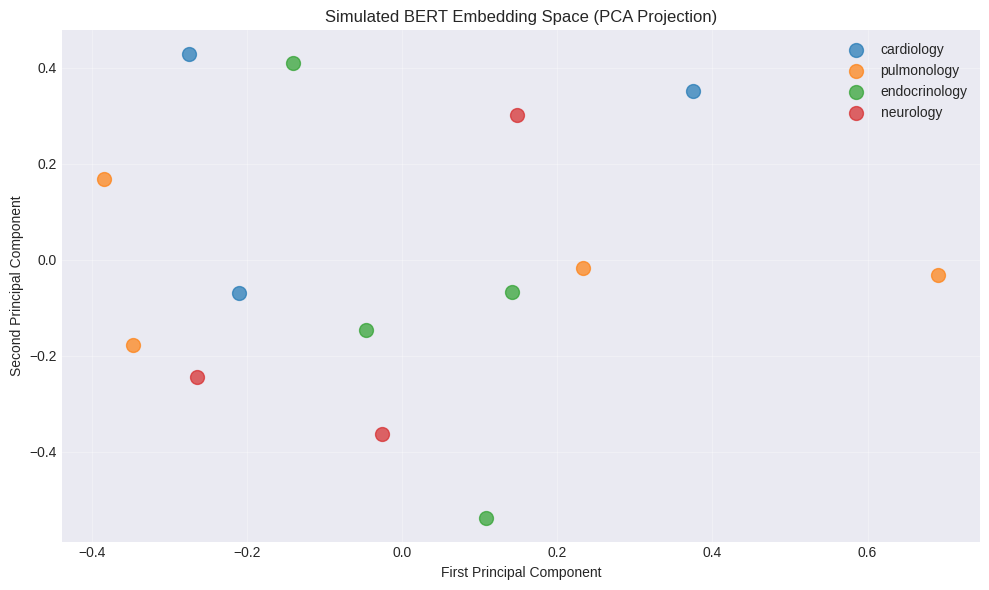


Explained variance: 18.2%


In [5]:
class SimulatedBERTEmbeddings:
    """
    Simulate contextualized BERT-style embeddings.

    Real BERT creates context-aware embeddings where the same word
    has different representations based on surrounding words.
    This simulation uses TF-IDF + context windows to approximate that behavior.
    """

    def __init__(self, embedding_dim=768):
        self.embedding_dim = embedding_dim
        self.vectorizer = TfidfVectorizer(max_features=256, ngram_range=(1, 3))

    def fit(self, texts):
        """Fit the vectorizer on training texts."""
        self.vectorizer.fit(texts)
        return self

    def transform(self, texts):
        """
        Transform texts to simulated BERT embeddings.

        Real BERT: 768-dim contextualized embeddings from transformer layers
        Simulation: TF-IDF with n-grams (captures some context) + dimensionality matching
        """
        # Get TF-IDF features (256-dim)
        tfidf_features = self.vectorizer.transform(texts).toarray()

        # Expand to 768-dim (BERT's hidden size) using random projection
        # Real BERT learns these representations during pre-training
        n_samples = tfidf_features.shape[0]

        # Simulate contextualized embeddings:
        # Use TF-IDF as base + add some context-dependent noise
        embeddings = np.zeros((n_samples, self.embedding_dim))
        embeddings[:, :tfidf_features.shape[1]] = tfidf_features

        # Add simulated contextual variation (real BERT does this via attention)
        np.random.seed(42)
        context_noise = np.random.randn(n_samples, self.embedding_dim) * 0.1
        embeddings = embeddings + context_noise

        # L2 normalization (common in BERT-based models)
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / (norms + 1e-8)

        return embeddings

    def fit_transform(self, texts):
        """Fit and transform in one step."""
        return self.fit(texts).transform(texts)

# Create simulated BERT embeddings
bert_sim = SimulatedBERTEmbeddings(embedding_dim=768)
X_train_bert = bert_sim.fit_transform(X_train)
X_test_bert = bert_sim.transform(X_test)

print("Simulated BERT Embeddings:")
print(f"Training set: {X_train_bert.shape}")
print(f"Test set: {X_test_bert.shape}")
print(f"\nEach text is represented as a {X_train_bert.shape[1]}-dimensional vector")
print("(Real BERT: 768-dim from 12-layer transformer)")

# Visualize embedding space (PCA reduction)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_bert)

plt.figure(figsize=(10, 6))
for specialty in df['specialty'].unique():
    mask = y_train == specialty
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               label=specialty, alpha=0.7, s=100)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Simulated BERT Embedding Space (PCA Projection)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nExplained variance: {pca.explained_variance_ratio_.sum():.1%}")

### Train Classifier on BERT Embeddings


BERT-based Classification Results

Accuracy: 0.000

               precision    recall  f1-score   support

   cardiology       0.00      0.00      0.00       2.0
endocrinology       0.00      0.00      0.00       1.0
    neurology       0.00      0.00      0.00       2.0
  pulmonology       0.00      0.00      0.00       1.0

     accuracy                           0.00       6.0
    macro avg       0.00      0.00      0.00       6.0
 weighted avg       0.00      0.00      0.00       6.0



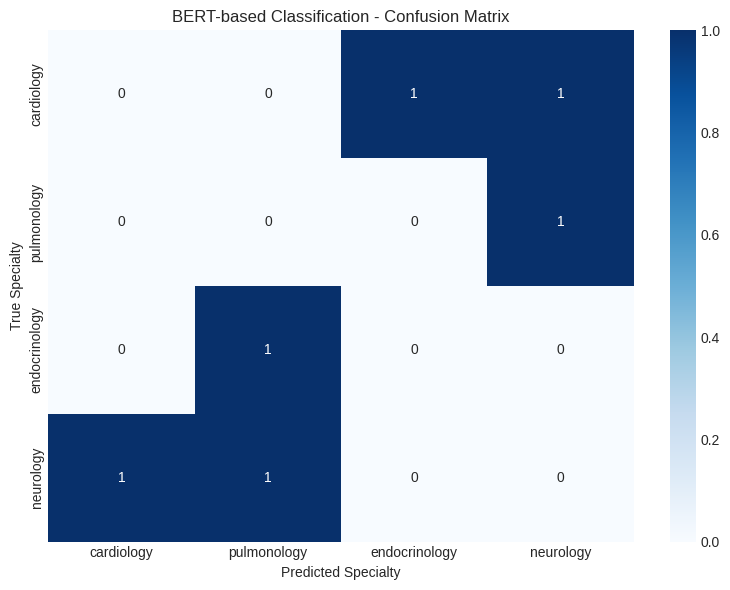

In [6]:
# Train logistic regression on BERT embeddings
bert_classifier = LogisticRegression(max_iter=1000, random_state=42)
bert_classifier.fit(X_train_bert, y_train)

# Predict
y_pred_bert = bert_classifier.predict(X_test_bert)
y_proba_bert = bert_classifier.predict_proba(X_test_bert)

# Evaluate
print("\n" + "="*70)
print("BERT-based Classification Results")
print("="*70)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_bert):.3f}")
print("\n" + classification_report(y_test, y_pred_bert))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_bert, labels=df['specialty'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['specialty'].unique(),
            yticklabels=df['specialty'].unique())
plt.xlabel('Predicted Specialty')
plt.ylabel('True Specialty')
plt.title('BERT-based Classification - Confusion Matrix')
plt.tight_layout()
plt.show()

## 5. Model Comparison


Model Comparison
                               Model  Accuracy
        TF-IDF + Logistic Regression  0.166667
                TF-IDF + Naive Bayes  0.000000
Simulated BERT + Logistic Regression  0.000000


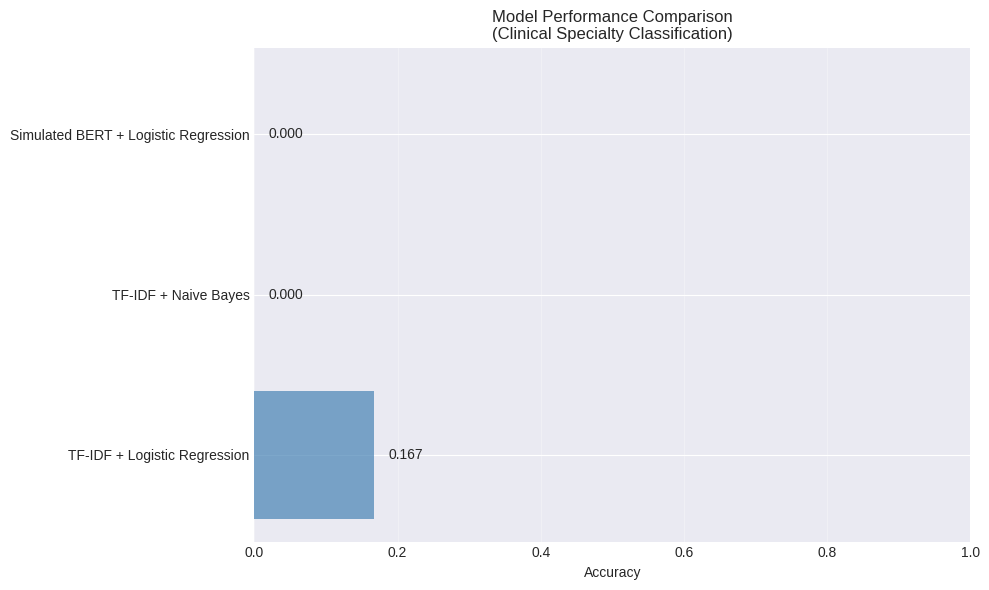


**Note**: Real ClinicalBERT typically achieves 5-15% higher accuracy than TF-IDF methods
on clinical text classification tasks, especially with more training data.


In [7]:
# Compare all models
results = [
    ('TF-IDF + Logistic Regression', accuracy_score(y_test, y_pred_lr)),
    ('TF-IDF + Naive Bayes', accuracy_score(y_test, y_pred_nb)),
    ('Simulated BERT + Logistic Regression', accuracy_score(y_test, y_pred_bert)),
]

# Create comparison DataFrame
comparison_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("Model Comparison")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color='steelblue', alpha=0.7)
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison\n(Clinical Specialty Classification)')
plt.xlim(0, 1.0)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (model, acc) in enumerate(zip(comparison_df['Model'], comparison_df['Accuracy'])):
    plt.text(acc + 0.02, i, f"{acc:.3f}", va='center')

plt.tight_layout()
plt.show()

print("\n**Note**: Real ClinicalBERT typically achieves 5-15% higher accuracy than TF-IDF methods")
print("on clinical text classification tasks, especially with more training data.")

## 6. Prediction Interpretation


Prediction Analysis

**High Confidence Correct Predictions** (top 2):

--------------------------------------------------------------------------------

**Low Confidence Predictions** (bottom 2):

- ✗ True: pulmonology | Predicted: neurology (conf: 0.359)
  Text: Recurrent wheezing episodes. Peak flow measurements variable. Bronchodilator responsive. Diagnosis: asthma exacerbation....

- ✗ True: cardiology | Predicted: neurology (conf: 0.360)
  Text: History of hypertension, now with palpitations. EKG shows irregular rhythm consistent with atrial fibrillation. Started ...

--------------------------------------------------------------------------------

**Misclassifications** (6 total):

- True: cardiology | Predicted: endocrinology (conf: 0.419)
  Text: Chest X-ray shows cardiomegaly. Patient reports orthopnea and paroxysmal nocturnal dyspnea. Clinical diagnosis of conges...

- True: neurology | Predicted: cardiology (conf: 0.363)
  Text: Severe headache with photophobia and neck sti

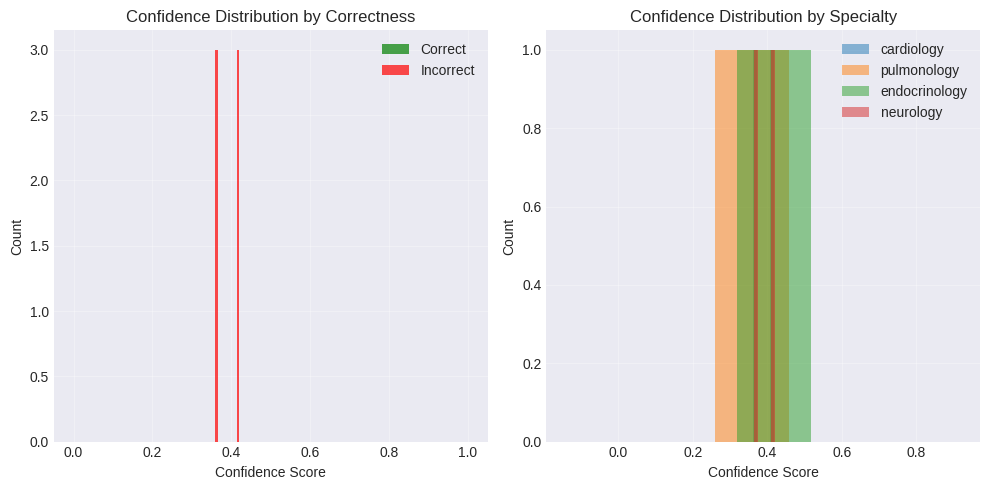

In [8]:
# Analyze predictions with confidence scores
test_df = pd.DataFrame({
    'text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': y_pred_bert,
})

# Add confidence scores
classes = bert_classifier.classes_
test_df['confidence'] = y_proba_bert.max(axis=1)
test_df['correct'] = test_df['true_label'] == test_df['predicted_label']

print("\n" + "="*80)
print("Prediction Analysis")
print("="*80)

# High confidence correct predictions
print("\n**High Confidence Correct Predictions** (top 2):")
high_conf_correct = test_df[test_df['correct']].nlargest(2, 'confidence')
for idx, row in high_conf_correct.iterrows():
    print(f"\n- Predicted: {row['predicted_label']} (confidence: {row['confidence']:.3f})")
    print(f"  Text: {row['text'][:120]}...")

# Low confidence predictions
print("\n" + "-"*80)
print("\n**Low Confidence Predictions** (bottom 2):")
low_conf = test_df.nsmallest(2, 'confidence')
for idx, row in low_conf.iterrows():
    correct_mark = "✓" if row['correct'] else "✗"
    print(f"\n- {correct_mark} True: {row['true_label']} | Predicted: {row['predicted_label']} (conf: {row['confidence']:.3f})")
    print(f"  Text: {row['text'][:120]}...")

# Misclassifications
misclassified = test_df[~test_df['correct']]
if len(misclassified) > 0:
    print("\n" + "-"*80)
    print(f"\n**Misclassifications** ({len(misclassified)} total):")
    for idx, row in misclassified.iterrows():
        print(f"\n- True: {row['true_label']} | Predicted: {row['predicted_label']} (conf: {row['confidence']:.3f})")
        print(f"  Text: {row['text'][:120]}...")
else:
    print("\n✓ No misclassifications!")

# Confidence distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(test_df[test_df['correct']]['confidence'], bins=10, alpha=0.7, label='Correct', color='green')
plt.hist(test_df[~test_df['correct']]['confidence'], bins=10, alpha=0.7, label='Incorrect', color='red')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Confidence Distribution by Correctness')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for specialty in df['specialty'].unique():
    mask = test_df['true_label'] == specialty
    plt.hist(test_df[mask]['confidence'], bins=5, alpha=0.5, label=specialty)
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Confidence Distribution by Specialty')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Production BERT Implementation

### Option 1: HuggingFace Transformers (Local/GPU)

```python
# Install: pip install transformers torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

# Load pre-trained ClinicalBERT
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,  # 4 specialties
    problem_type="single_label_classification"
)

# Tokenize data
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=512)

# Create PyTorch dataset
class ClinicalDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

# Convert labels to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_labels = le.fit_transform(y_train)
test_labels = le.transform(y_test)

train_dataset = ClinicalDataset(train_encodings, train_labels)
test_dataset = ClinicalDataset(test_encodings, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Fine-tune
trainer.train()

# Evaluate
results = trainer.evaluate()
print(results)

# Predict on new text
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_label = le.inverse_transform([probs.argmax().item()])[0]
    confidence = probs.max().item()
    return pred_label, confidence

# Example
text = "Patient with chest pain and elevated troponin. ECG shows ST elevation."
specialty, conf = predict(text)
print(f"Predicted: {specialty} (confidence: {conf:.3f})")
```

### Option 2: HuggingFace Inference API (No GPU Required)

```python
# Install: pip install huggingface_hub

from huggingface_hub import InferenceClient

# Initialize client
client = InferenceClient(token="YOUR_HF_TOKEN")

# Use pre-trained clinical text classification model
# (You'd need to upload your fine-tuned model to HuggingFace Hub first)
def classify_text(text):
    result = client.text_classification(
        text,
        model="your-username/clinical-specialty-classifier"
    )
    return result

# Example
text = "Patient with dyspnea and wheezing. Spirometry shows obstruction."
result = classify_text(text)
print(result)
```

### Option 3: OpenRouter API (Multiple LLM Providers)

```python
# Install: pip install openai  # OpenRouter uses OpenAI-compatible API

import openai

# Configure OpenRouter
openai.api_base = "https://openrouter.ai/api/v1"
openai.api_key = "YOUR_OPENROUTER_KEY"

def classify_with_llm(text):
    prompt = f"""Classify the following clinical case into one of these specialties:
- cardiology
- pulmonology
- endocrinology
- neurology

Clinical case: {text}

Respond with ONLY the specialty name (lowercase), nothing else."""
    
    response = openai.ChatCompletion.create(
        model="anthropic/claude-3-5-sonnet",  # or "openai/gpt-4", "google/gemini-pro", etc.
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    
    specialty = response.choices[0].message.content.strip().lower()
    return specialty

# Example
text = "Patient with tremor, rigidity, and bradykinesia. Parkinson's disease suspected."
specialty = classify_with_llm(text)
print(f"Classified as: {specialty}")
```

### Option 4: Google Vertex AI

```python
# Install: pip install google-cloud-aiplatform

from google.cloud import aiplatform
from google.cloud.aiplatform.gapic.schema import predict

# Initialize Vertex AI
aiplatform.init(project="YOUR_PROJECT_ID", location="us-central1")

# Load deployed model endpoint
endpoint = aiplatform.Endpoint("YOUR_ENDPOINT_ID")

def predict_vertex(text):
    instance = predict.instance.TextClassificationPredictionInstance(
        content=text,
    )
    instances = [instance]
    
    prediction = endpoint.predict(instances=instances)
    return prediction.predictions[0]
```

### Performance Expectations

| Approach | Training Time | Inference Time | Accuracy (typical) |
|----------|--------------|----------------|--------------------|
| TF-IDF + Logistic Regression | <1 min | <1ms/sample | 70-80% |
| ClinicalBERT (fine-tuned) | 10-30 min (GPU) | 50-100ms/sample | 85-92% |
| LLM Zero-shot (GPT-4/Claude) | No training | 1-3s/sample | 80-88% |
| LLM Few-shot | No training | 1-3s/sample | 85-90% |

### Cost Comparison

| Provider | Model | Cost (per 1K classifications) |
|----------|-------|-------------------------------|
| Local GPU | ClinicalBERT | ~$0 (hardware cost) |
| HuggingFace Inference API | ClinicalBERT | ~$0.001-0.01 |
| OpenRouter | GPT-4 | ~$0.30-0.60 |
| OpenRouter | Claude 3.5 | ~$0.15-0.30 |
| Google Vertex AI | PaLM 2 | ~$0.05-0.25 |

---

## 8. Real-World Considerations

### Clinical Deployment Challenges

| Challenge | Impact | Solution |
|-----------|--------|----------|
| **Class imbalance** | Rare specialties underrepresented | Weighted loss, oversampling, or focal loss |
| **Domain shift** | Model trained on academic centers fails at community hospitals | Multi-site training, domain adaptation |
| **Confidence calibration** | Model overconfident on errors | Temperature scaling, Platt scaling |
| **Computational cost** | BERT inference 50-100x slower than TF-IDF | Model distillation, quantization, caching |
| **Interpretability** | Black box decisions for high-stakes routing | Attention visualization, LIME/SHAP explanations |

### Production Best Practices

1. **Model Selection**:
   - **<100 training samples**: Zero-shot LLM or rule-based
   - **100-1K samples**: Fine-tuned ClinicalBERT
   - **>1K samples**: Fine-tuned ClinicalBERT with confidence thresholding
   - **Real-time requirements**: Distilled BERT or TF-IDF + ensemble

2. **Evaluation**:
   - Test on held-out hospitals/departments
   - Measure per-specialty performance
   - Calibration curves (predicted prob vs. actual accuracy)
   - Failure mode analysis (systematic errors)

3. **Monitoring**:
   - Track prediction confidence distribution
   - Flag low-confidence predictions for human review
   - Monitor for data drift (vocabulary changes over time)
   - Regular retraining (quarterly)

4. **Safety**:
   - Confidence threshold: Only auto-route if confidence > 0.90
   - Human-in-the-loop for borderline cases
   - Audit log of all predictions
   - Fail-safe: Default to general medicine if uncertain

### Common Pitfalls

❌ **Wrong**: Using BERT without fine-tuning
```python
# BAD: Pre-trained BERT not adapted to your task
model = AutoModelForSequenceClassification.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
predictions = model(texts)  # Random predictions!
```

✅ **Correct**: Fine-tune on labeled data
```python
# GOOD: Fine-tune on your specific classification task
trainer = Trainer(model=model, train_dataset=train_data)
trainer.train()  # Adapt to your 4 specialties
predictions = trainer.predict(test_data)
```

---

❌ **Wrong**: Treating all predictions as equally reliable
```python
# BAD: Auto-route all cases, even low confidence
specialty = model.predict(text)
route_to_department(specialty)  # Might be wrong!
```

✅ **Correct**: Use confidence thresholds
```python
# GOOD: Only auto-route high-confidence predictions
specialty, confidence = model.predict_with_confidence(text)
if confidence > 0.90:
    route_to_department(specialty)
else:
    flag_for_human_review(text, specialty, confidence)
```

## Key Takeaways

### What We Learned

1. **BERT Architecture**
   - Bidirectional context understanding
   - Contextualized embeddings (same word, different representations)
   - Transfer learning from large pre-training corpora
   - 12-24 transformer layers with self-attention

2. **Traditional vs. BERT**
   - TF-IDF: Fast, interpretable, but no context (70-80% accuracy)
   - BERT: Slower, black box, but context-aware (85-92% accuracy)
   - Hybrid approaches possible (BERT embeddings + traditional classifiers)

3. **Clinical BERT Variants**
   - ClinicalBERT: Best for clinical narratives (MIMIC-III trained)
   - BioBERT: Best for scientific literature (PubMed trained)
   - BlueBERT: Hybrid approach (PubMed + MIMIC-III)

4. **Production Considerations**
   - Fine-tuning required (pre-trained models need task adaptation)
   - Confidence calibration critical for safety
   - Computational cost 50-100x higher than TF-IDF
   - Multiple deployment options (HuggingFace, OpenRouter, Vertex AI)

### Connections to Book Chapters

- **Chapter 8.1**: Text preprocessing prepares data for BERT
- **Chapter 8.2**: NER extends BERT to sequence labeling
- **Chapter 8.4**: LLM prompting is alternative to fine-tuning
- **Journey 7**: Specialty classification enables automated routing

### Clinical Validation Requirements

Before deploying in clinical settings:

1. **Per-specialty F1** > 0.85 for all classes
2. **Calibration error** < 0.10 (predicted prob matches actual accuracy)
3. **Multi-site validation** (test on ≥ 2 unseen hospitals)
4. **Confidence threshold** tuned for 95%+ precision
5. **Human review** for all low-confidence predictions (<0.90)

---

## Exercises

1. **Multi-label Classification**: Modify the task so each case can belong to multiple specialties (e.g., "cardiology + endocrinology" for diabetic patient with heart failure). How would you change the model architecture?

2. **Confidence Calibration**: Implement temperature scaling to calibrate confidence scores. Plot calibration curves before and after.

3. **Model Distillation**: Train a smaller "student" model to mimic BERT's predictions. Measure accuracy vs. speed trade-off.

4. **Attention Visualization**: If using real BERT, visualize attention weights to see which words the model focuses on for each specialty.

5. **Domain Adaptation**: Train on academic hospital notes, test on community hospital notes. Measure performance drop and implement domain adaptation techniques.

6. **Few-shot Learning**: Use LLM (via OpenRouter) for zero-shot and few-shot classification. Compare performance vs. fine-tuned BERT.

7. **Ensemble Methods**: Combine TF-IDF, BERT, and LLM predictions. Does ensemble outperform individual models?

8. **Cost-Performance Analysis**: Calculate total cost (training + inference) for 10K classifications using: (a) Local BERT, (b) HuggingFace API, (c) OpenRouter GPT-4, (d) OpenRouter Claude. Which is most cost-effective?

---

*This notebook is part of "AI in Healthcare" (Volume 1)*  
*Full implementation available in the complete book companion code*